# Supermarket Sales Analysis — Data Analytics Project

**Student:** Saket Kumar Mahato  
**Program:** IBM SkillsBuild Data Analytics with AI Academic Internship Program  
**Institute:** Bangalore Institute of Technology

## Objective
Analyze supermarket transactions to understand sales performance across products, branches, categories, payment methods, customer types, ratings, and dates.

### Masterclass alignment
This notebook directly applies Masterclass 2 skills: dataset exploration, data-quality checks, KPI summaries, grouping/aggregation, pivot analysis, visualization, and evidence-based observations.

Masterclass 3 introduced RFM, churn prediction, logistic regression, classification metrics, risk scoring, target leakage, and association-vs-causation. Those are documented as **learned concepts/future scope**, not claimed as implemented here, because this dataset has no persistent `Customer_ID` or sufficient customer-level history for a valid churn model.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


file_path = "C:\\Users\\saket\\Downloads\\SUPER MARKET DATA.xlsx"
df = pd.read_excel(file_path, sheet_name="supermarket_sales_500_rows")
df.head()


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.80,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.90,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.40,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.50,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.10,652.85


## 1. Dataset exploration

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nFirst 5 rows:")
display(df.head())

for col in ["Branch", "City", "Customer Type", "Gender", "Product", "Category", "Payment"]:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].dropna().unique())


Rows: 500
Columns: 13

Column names:
['Invoice ID', 'Date', 'Branch', 'City', 'Customer Type', 'Gender', 'Product', 'Category', 'Quantity', 'Unit Price', 'Payment', 'Rating', 'Sales']

Data types:


,dtype
Invoice ID,object
Date,datetime64[ns]
Branch,object
City,object
Customer Type,object
Gender,object
Product,object
Category,object
Quantity,int64
Unit Price,float64



First 5 rows:


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.80,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.90,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.40,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.50,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.10,652.85



Branch: 4 unique values
['A' 'C' 'B' 'D']

City: 4 unique values
['Jaipur' 'Mumbai' 'Delhi' 'Bengaluru']

Customer Type: 2 unique values
['Member' 'Normal']

Gender: 2 unique values
['Male' 'Female']

Product: 20 unique values
['Milk' 'Rice' 'Shampoo' 'Apples' 'Soap' 'Cooking Oil' 'Potato' 'Biscuits'
 'Chips' 'Cold Drink' 'Coffee' 'Tomato' 'Bread' 'Face Wash' 'Tea'
 'Noodles' 'Cheese' 'Bananas' 'Chocolate' 'Eggs']

Category: 8 unique values
['Dairy' 'Grocery' 'Personal Care' 'Fruits' 'Vegetables' 'Snacks'
 'Beverages' 'Bakery']

Payment: 4 unique values
['UPI' 'Net Banking' 'Card' 'Cash']


## 2. Data quality and validation

In [4]:
print("Missing values by column:")
display(df.isna().sum().to_frame("missing_values"))

print("Duplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

df["Calculated Sales"] = df["Quantity"] * df["Unit Price"]
df["Sales Difference"] = (df["Sales"] - df["Calculated Sales"]).abs()

print("Maximum absolute difference:", df["Sales Difference"].max())
assert df["Sales Difference"].max() < 1e-9
print("Sales validation passed.")


Missing values by column:


,missing_values
Invoice ID,0
Date,0
Branch,0
City,0
Customer Type,0
Gender,0
Product,0
Category,0
Quantity,0
Unit Price,0


Duplicate rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice ID,500,500,INV0500,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,500,NaN,NaN,NaN,2026-04-03 12:25:55.199999744,2026-01-01 00:00:00,2026-02-17 00:00:00,2026-04-09 00:00:00,2026-05-17 06:00:00,2026-07-01 00:00:00,NaN
Branch,500,4,C,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,500,4,Mumbai,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,500,2,Member,296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,500,2,Female,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,500,20,Rice,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,500,8,Grocery,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,500.00,NaN,NaN,NaN,5.54,1.00,3.00,5.50,8.00,10.00,2.88
Unit Price,500.00,NaN,NaN,NaN,88.66,27.67,43.95,61.88,128.57,236.71,57.28


Maximum absolute difference: 4.547473508864641e-13
Sales validation passed.


## 3. KPI summary

In [5]:
kpi = pd.Series({
    "Total Sales": df["Sales"].sum(),
    "Average Transaction": df["Sales"].mean(),
    "Total Quantity Sold": df["Quantity"].sum(),
    "Average Rating": df["Rating"].mean(),
    "Number of Transactions": df["Invoice ID"].nunique()
})
display(kpi.to_frame("Value"))


,Value
Total Sales,"244,411.08"
Average Transaction,488.82
Total Quantity Sold,"2,768.00"
Average Rating,3.99
Number of Transactions,500.00


## 4. Product-wise sales

,Total Sales
Product,
Cheese,"27,906.30"
Coffee,"27,694.87"
Shampoo,"27,497.48"
Cooking Oil,"21,525.06"
Tea,"17,681.59"
Apples,"17,057.41"
Face Wash,"11,946.85"
Rice,"11,754.17"
Cold Drink,"10,731.78"


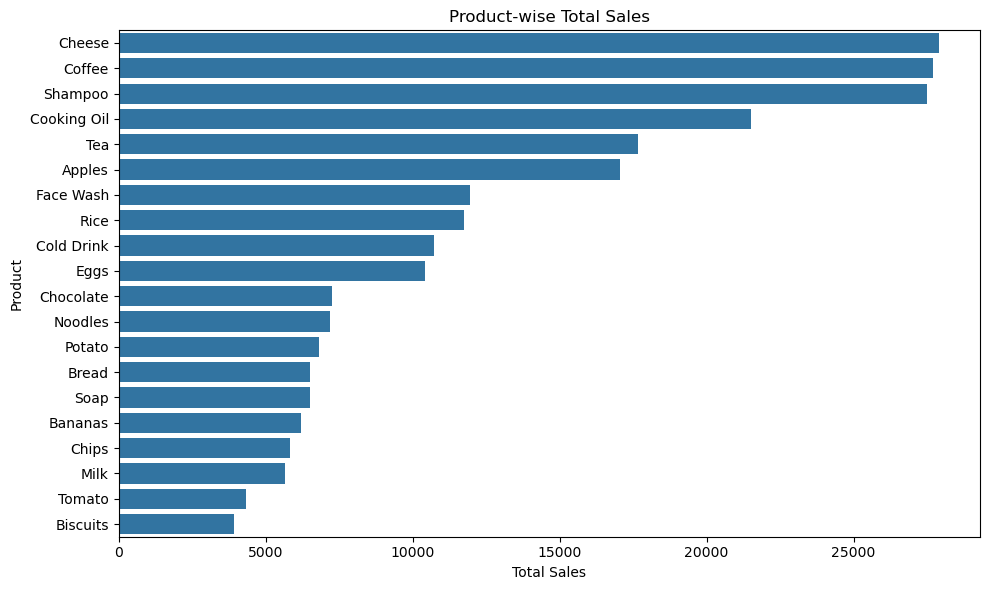

In [6]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
display(product_sales.to_frame("Total Sales"))

plt.figure(figsize=(10,6))
sns.barplot(x=product_sales.values, y=product_sales.index)
plt.title("Product-wise Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


## 5. Branch-wise sales

,,Total Sales
Branch,City,
C,Mumbai,"72,469.45"
B,Delhi,"64,116.26"
D,Bengaluru,"55,468.29"
A,Jaipur,"52,357.08"


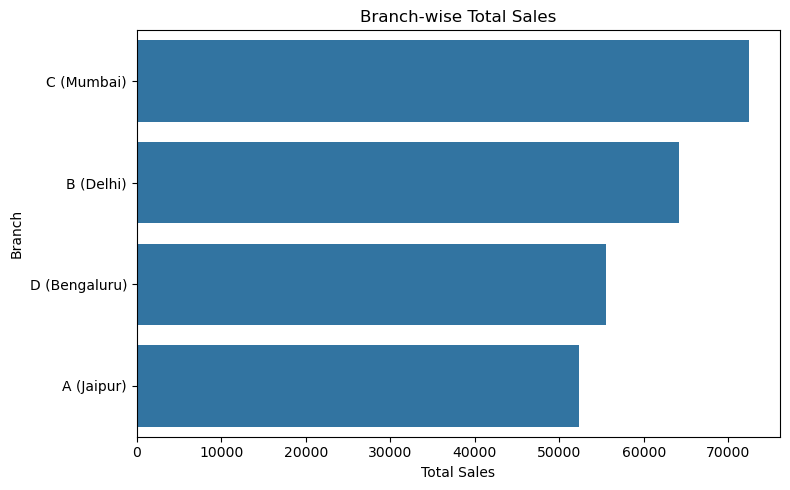

In [7]:
branch_sales = df.groupby(["Branch", "City"])["Sales"].sum().sort_values(ascending=False)
display(branch_sales.to_frame("Total Sales"))

plt.figure(figsize=(8,5))
sns.barplot(x=branch_sales.values, y=[f"{b} ({c})" for b,c in branch_sales.index])
plt.title("Branch-wise Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Branch")
plt.tight_layout()
plt.show()


## 6. Category-wise sales

,Total Sales
Category,
Beverages,"56,108.24"
Personal Care,"45,943.96"
Dairy,"43,992.00"
Grocery,"40,470.47"
Fruits,"23,263.17"
Snacks,"16,992.97"
Vegetables,"11,124.17"
Bakery,"6,516.10"


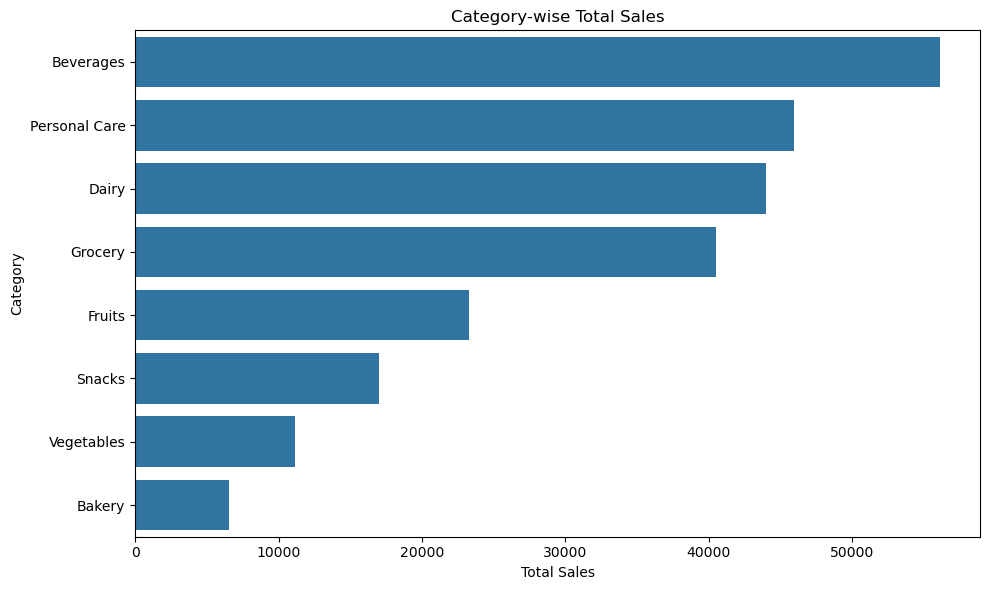

In [8]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
display(category_sales.to_frame("Total Sales"))

plt.figure(figsize=(10,6))
sns.barplot(x=category_sales.values, y=category_sales.index)
plt.title("Category-wise Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


## 7. Payment method analysis

,Transactions
Payment,
UPI,127
Net Banking,126
Card,125
Cash,122


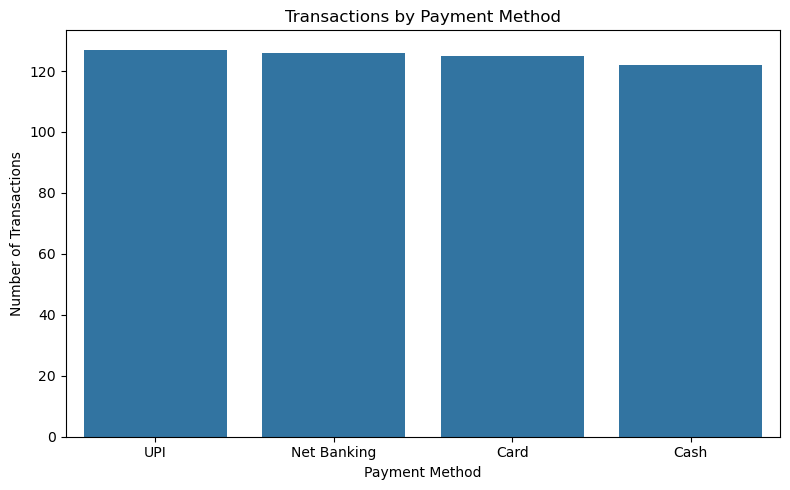

In [9]:
payment_counts = df["Payment"].value_counts().sort_values(ascending=False)
display(payment_counts.to_frame("Transactions"))

plt.figure(figsize=(8,5))
sns.barplot(x=payment_counts.index, y=payment_counts.values)
plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


## 8. Customer type analysis

,Average Transaction
Customer Type,
Normal,497.07
Member,483.14


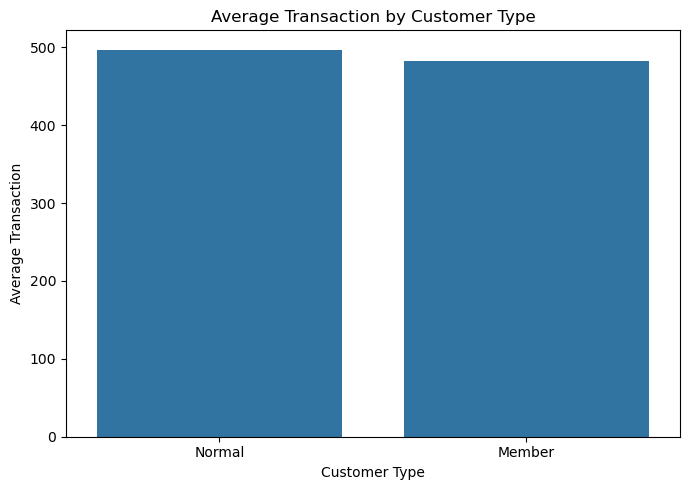

In [10]:
customer_avg = df.groupby("Customer Type")["Sales"].mean().sort_values(ascending=False)
display(customer_avg.to_frame("Average Transaction"))

plt.figure(figsize=(7,5))
sns.barplot(x=customer_avg.index, y=customer_avg.values)
plt.title("Average Transaction by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Transaction")
plt.tight_layout()
plt.show()


## 9. Rating analysis

Average rating: 3.99


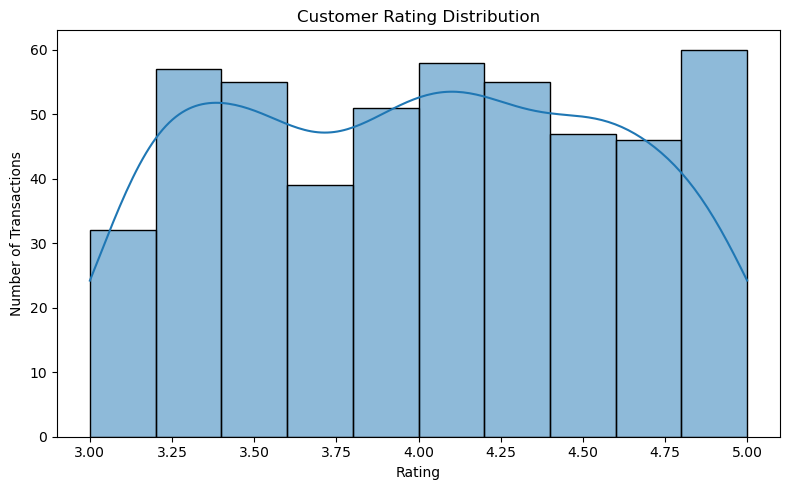

In [11]:
print("Average rating:", round(df["Rating"].mean(), 2))

plt.figure(figsize=(8,5))
sns.histplot(df["Rating"], bins=10, kde=True)
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


## 10. Daily sales trend

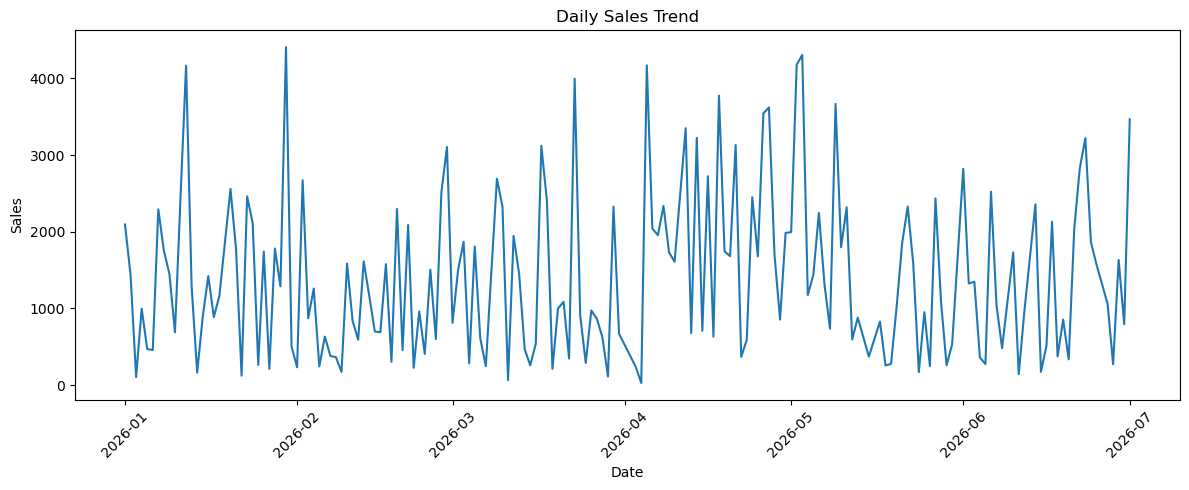

In [12]:
df["Date"] = pd.to_datetime(df["Date"])
daily_sales = df.groupby("Date")["Sales"].sum().sort_index()

plt.figure(figsize=(12,5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Branch × Category pivot analysis

Category,Bakery,Beverages,Dairy,Fruits,Grocery,Personal Care,Snacks,Vegetables
Branch,,,,,,,,
A,"1,860.45","7,934.12","10,674.63","4,986.25","9,277.61","12,119.24","2,994.70","2,510.08"
B,"1,990.01","18,218.06","10,516.22","8,625.88","6,750.82","11,425.62","3,564.92","3,024.73"
C,"1,130.45","11,637.59","16,203.23","7,306.09","13,254.70","15,312.00","4,803.03","2,822.36"
D,"1,535.19","18,318.47","6,597.92","2,344.95","11,187.34","7,087.10","5,630.32","2,767.00"


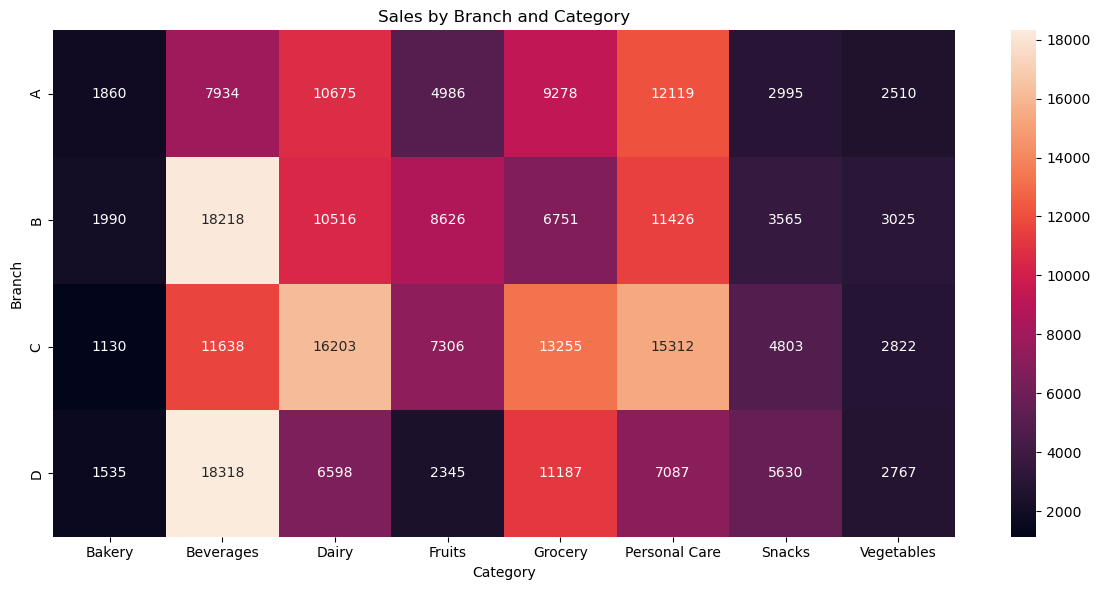

In [13]:
branch_category = pd.pivot_table(
    df, values="Sales", index="Branch", columns="Category",
    aggfunc="sum", fill_value=0
)
display(branch_category)

plt.figure(figsize=(12,6))
sns.heatmap(branch_category, annot=True, fmt=".0f")
plt.title("Sales by Branch and Category")
plt.xlabel("Category")
plt.ylabel("Branch")
plt.tight_layout()
plt.show()


## 12. AI-assisted analytical interpretation

Masterclass 2 emphasizes using AI to help discover patterns and then checking those observations against the data.

### Key observations
- **Cheese** has the highest product-level sales.
- **Branch C (Mumbai)** has the highest branch-level sales.
- **Beverages** is the highest-selling category.
- **UPI** is the most frequently used payment method, with 127 transactions.
- The average transaction is slightly higher for **Normal** customers than **Member** customers in this sample.
- The average customer rating is about **4.0/5**.
- Daily sales vary across dates.

These are descriptive patterns in the recorded transactions. They do **not** prove why the differences exist.


## 13. Business questions and answers

In [14]:
answers = {
    "Highest-selling product": product_sales.index[0],
    "Highest product sales": product_sales.iloc[0],
    "Highest-performing branch": f"{branch_sales.index[0][0]} ({branch_sales.index[0][1]})",
    "Highest branch sales": branch_sales.iloc[0],
    "Highest-selling category": category_sales.index[0],
    "Highest category sales": category_sales.iloc[0],
    "Most-used payment method": payment_counts.index[0],
    "Transactions using most-used payment": payment_counts.iloc[0],
    "Customer type with higher average transaction": customer_avg.index[0],
    "Average rating": df["Rating"].mean()
}
display(pd.Series(answers).to_frame("Result"))


,Result
Highest-selling product,Cheese
Highest product sales,"27,906.30"
Highest-performing branch,C (Mumbai)
Highest branch sales,"72,469.45"
Highest-selling category,Beverages
Highest category sales,"56,108.24"
Most-used payment method,UPI
Transactions using most-used payment,127
Customer type with higher average transaction,Normal
Average rating,3.99


## 14. Business insights and decisions

1. Monitor high-sales products and categories for inventory planning.
2. Study Branch C further to understand its observed sales pattern.
3. Monitor the Beverages category closely.
4. Maintain reliable UPI support because it is the most-used payment method in this sample.
5. Track Member vs Normal transaction values before designing membership offers.
6. Track ratings alongside sales as a customer-experience indicator.
7. Collect customer-level historical data in future projects for segmentation and predictive analytics.


## 15. Masterclass 3 concepts learned — scope and limitations

Learned concepts:
- Customer-level aggregation
- RFM (Recency, Frequency, Monetary)
- Churn target definition
- Logistic regression
- Accuracy, precision, recall, confusion matrix
- Churn probability and risk levels
- Precision–recall trade-offs
- Target leakage
- Association versus causation

These are **not implemented in this supermarket notebook** because the dataset lacks a persistent `Customer_ID` and sufficient customer purchase history. A suitable e-commerce/customer dataset with historical purchases would be needed for a valid churn workflow.


## 16. Technologies used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook
- Excel/tabular data


## 17. Conclusion

The project converts raw supermarket transactions into business information through data loading, quality checks, KPI analysis, groupby aggregation, pivot analysis, visualization, and careful interpretation.

Masterclass 2 is directly reflected in the implemented EDA workflow. Masterclass 3 is represented honestly as transferable learning and future scope rather than unsupported churn-model implementation.
